Notebook 302: Análisis de Distribución y Patología Salarial (AWW)

--- MÉTRICAS DE MOMENTO (N-ACTIVO: 2,219,112) ---
Media: $949.73
Mediana: $752.50
Skewness (Sesgo): 285.19
Kurtosis (Curtosis): 100947.32


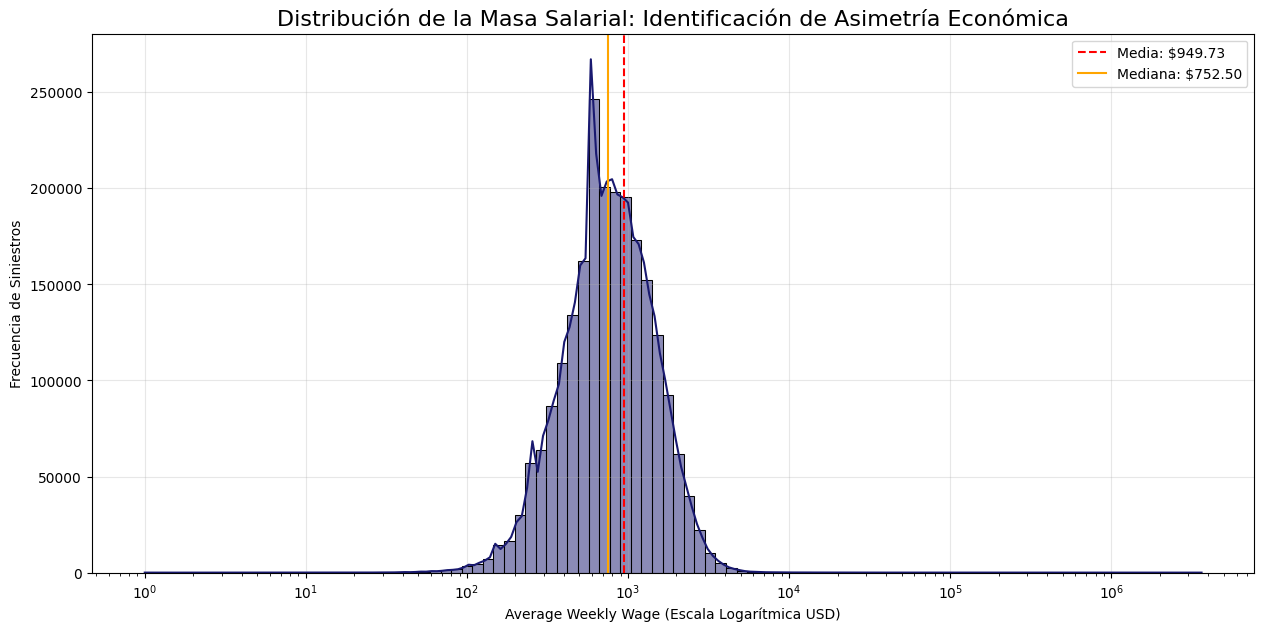

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# ===========================================================================
# 302.1 CARGA Y RECONSTRUCCIÓN DEL CONTEXTO
# ===========================================================================
# Cargamos el dataset sanitizado. En una arquitectura profesional, 
# cada capítulo inicia con la carga del checkpoint previo.
path_raw = r'C:\Tesis_ML\raw_data\nyswcb_claims.csv'
df = pd.read_csv(path_raw, low_memory=False)

# Sanitización de cabeceras (procedimiento estándar del Capítulo 1)
df.columns = [c.strip().replace('\r', '').replace('\n', '') for c in df.columns]

# ===========================================================================
# 302.2 TRATAMIENTO SOBERANO DEL AWW (Average Weekly Wage)
# ===========================================================================
target_wage = 'Average Weekly Wage (AWW)'

# Limpieza coercitiva: Eliminamos ruidos de caracteres ($, comas) y forzamos float
df[target_wage] = pd.to_numeric(df[target_wage].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Gestión de la Incertidumbre: Los NaN se tratan inicialmente como 0 
# para cuantificar la "Información No Determinada"
df[target_wage] = df[target_wage].fillna(0)

# ===========================================================================
# 302.3 DIAGNÓSTICO DE MOMENTOS ESTADÍSTICOS Y SESGO
# ===========================================================================
# Filtramos la masa salarial activa (>0) para el análisis de distribución
wage_active = df[df[target_wage] > 0][target_wage]

print(f"--- MÉTRICAS DE MOMENTO (N-ACTIVO: {len(wage_active):,}) ---")
print(f"Media: ${wage_active.mean():.2f}")
print(f"Mediana: ${wage_active.median():.2f}")
print(f"Skewness (Sesgo): {skew(wage_active):.2f}")
print(f"Kurtosis (Curtosis): {kurtosis(wage_active):.2f}")

# ===========================================================================
# 302.4 VISUALIZACIÓN ESTRATÉGICA PARA LA TESIS
# ===========================================================================
plt.figure(figsize=(15, 7))

# Histograma con escala logarítmica para visualizar la cola larga (Long-tail)
sns.histplot(wage_active, bins=100, kde=True, color='midnightblue', log_scale=True)

plt.axvline(wage_active.mean(), color='red', linestyle='--', label=f'Media: ${wage_active.mean():.2f}')
plt.axvline(wage_active.median(), color='orange', linestyle='-', label=f'Mediana: ${wage_active.median():.2f}')

plt.title('Distribución de la Masa Salarial: Identificación de Asimetría Económica', fontsize=16)
plt.xlabel('Average Weekly Wage (Escala Logarítmica USD)')
plt.ylabel('Frecuencia de Siniestros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()